# Local UITI_VANO Interpretability

Notebook-first workflow for steps 1-3: circuit/date selection, deterministic critical-point detection, structured context, and optional LLM interpretation.

## 1. Setup and parameters

In [1]:
%load_ext autoreload
%autoreload 2

import json
import os
import sys
from datetime import datetime, timezone
from pathlib import Path

try:
    from dotenv import load_dotenv
except ImportError:
    load_dotenv = None

# 1. Dynamically locate the project root by finding the 'src' directory
ROOT = Path.cwd().resolve()
while not (ROOT / "src").is_dir() and ROOT.parent != ROOT:
    ROOT = ROOT.parent

# 2. Add 'src' to sys.path so Python can find project packages
src_path = str(ROOT / "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

# 3. Load environment variables (.env tiene prioridad; si no existe, usa .env.example)
if load_dotenv:
    _env_file = ROOT / ".env" if (ROOT / ".env").exists() else ROOT / ".env.example"
    load_dotenv(_env_file)
    print(f"Config cargada desde: {_env_file.name}")

# 4. Import project modules
from chec_local_interpreter.attribution import enrich_critical_points
from chec_local_interpreter.config import CriticalityThresholds, DEFAULT_DATA_PATH, MAX_CRITICAL_POINTS as DEFAULT_MAX_CRITICAL_POINTS
from chec_local_interpreter.context_builder import build_context_package, critical_points_frame, save_json_artifact
from chec_local_interpreter.critical_points import build_daily_series, compute_daily_features, detect_critical_periods, detect_point_reasons, rank_critical_points
from chec_local_interpreter.data_loader import available_circuits, dataset_summary, filter_events, load_dataset, resolve_columns
from chec_local_interpreter.llm_client import call_llm, save_cot_html_graph
from chec_local_interpreter.llm_contracts import PROMPT_VERSION, load_output_schema, render_prompt, save_prompt_artifact
from chec_local_interpreter.llm_skills import assemble_skill_bundle, list_available_skills, verify_required_skills
from chec_local_interpreter.llm_validation import save_invalid_output, validate_llm_response
from chec_local_interpreter.plotting import save_uiti_vano_plot, plot_interactive_critical_points

# =======================================================
# Configuración común elegida por el usuario
# =======================================================
DATA_PATH = str(ROOT / "data/Indicadores_vano_v3.csv")
SELECTED_CIRCUITOS = ['CHA23L18']#["DON23L13"]
START_DATE = None  # Ej.: "2025-11-01 00:00:01"; None usa el inicio disponible.
END_DATE = None    # Ej.: "2026-04-30 21:53:40"; None usa el fin disponible.
MAX_CRITICAL_POINTS = 5
OUTPUT_DIR = Path("outputs")
CALL_LLM = True
_configured_provider = os.getenv("LLM_PROVIDER")
if _configured_provider:
    LLM_PROVIDER = _configured_provider
elif os.getenv("GOOGLE_API_KEY", "").strip():
    LLM_PROVIDER = "google"
elif os.getenv("OPENAI_API_KEY", "").strip():
    LLM_PROVIDER = "openai"
else:
    LLM_PROVIDER = "ollama"

if LLM_PROVIDER.lower() == "ollama":
    LLM_MODEL = os.getenv("LLM_MODEL") or os.getenv("OLLAMA_MODEL", "deepseek-r1:32b")
elif LLM_PROVIDER.lower() == "openai":
    LLM_MODEL = os.getenv("LLM_MODEL", "gpt-4.1-mini")
else:
    LLM_MODEL = os.getenv("LLM_MODEL", "gemini-2.5-flash-lite")

# Fechas para el escenario TabNet 8.5. None usa los días de critical_points.
FECHAS_INTERES_USUARIO = None

# Parámetros TabNet / SHAP comunes a 8.1-8.7
TOP_N_VANOS = 97
TOP_K_VARS = 20
SHAP_BACKGROUND_SIZE = 40
SHAP_NSAMPLES = 80
SHAP_BATCH_SIZE = 64
SHAP_RANDOM_STATE = 42
FILTRO_UITI_MAX = 1000
VENTANA_CLIMATICA_HORAS = 12
VARIABLES_SELECCION_PATH = ROOT / "data" / "Variables_seleccion.xlsx"
MODEL_PATH = ROOT / "data" / "models" / "best_tabnet_classifier_model.zip"


Config cargada desde: .env


## 2. Load data

In [2]:
import pandas as pd
raw_df = load_dataset(DATA_PATH)
column_resolution = resolve_columns(raw_df)
summary = dataset_summary(raw_df)
available = available_circuits(raw_df)
selected_label = SELECTED_CIRCUITOS if SELECTED_CIRCUITOS else "all circuits"
print(f"Dataset shape: {summary['shape']}")
print(f"Date range: {summary['date_min']} to {summary['date_max']}")
print(f"Available circuits: {summary['available_circuits_count']}")
print(f"Selected circuits parameter: {selected_label}")
print(f"Unavailable optional columns: {len(column_resolution.unavailable_optional)}")


Dataset shape: [159470, 273]
Date range: 2025-11-01 to 2026-04-30
Available circuits: 208
Selected circuits parameter: ['CHA23L18']
Unavailable optional columns: 0


In [3]:
raw_df.head()

,CIRCUITO,FID_SW,COD_EQ_PROTEGE,FID_VANO,T_USUS_EQ_PROT,LVSW,CNT_VN,CNT_VN_SW,FECHA,DURACION,...,clouds_15,clouds_16,clouds_17,clouds_18,clouds_19,clouds_20,clouds_21,clouds_22,clouds_23,clouds_24
0,AGU23L14,20142930,AGU23L14,20139439,1821,2.568,16,22,2025-11-03 23:56:04,0.008,...,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
1,AGU23L14,20142930,AGU23L14,20139439,1821,2.568,16,22,2025-11-18 17:08:14,0.008,...,100.0,100.0,84.0,99.0,99.0,98.0,98.0,97.0,98.0,100.0
2,AGU23L14,20142930,AGU23L14,20139439,1821,2.568,16,22,2025-11-19 20:25:50,0.008,...,79.0,99.0,100.0,100.0,100.0,97.0,100.0,100.0,99.0,98.0
3,AGU23L14,20142930,AGU23L14,20139439,1821,2.568,16,22,2025-12-10 21:33:41,0.008,...,69.0,93.0,100.0,55.0,61.0,32.0,56.0,59.0,58.0,76.0
4,AGU23L14,20142930,AGU23L14,20139439,1821,2.568,16,22,2025-12-19 15:59:10,0.041,...,99.0,97.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0


## 2.1 Circuit Histograms: number of events and UITI

In [4]:
from chec_local_interpreter.plotting import plot_interactive_circuit_events

# =======================================================
# EJEMPLOS DE USO:
# =======================================================

# 1. Utilizar todo el intervalo de datos (sin filtrar)
fig = plot_interactive_circuit_events(raw_df)
fig.show()

# 2. Utilizar un intervalo de fechas específico
#fig = plot_interactive_circuit_events(raw_df, start_date='2025-11-01 00:00:01', end_date='2025-12-01 00:00:01')
#fig.show()


In [5]:
from chec_local_interpreter.plotting import plot_interactive_uiti_vano_sums

# =======================================================
# EJEMPLOS DE USO:
# =======================================================

# 1. Utilizar todo el intervalo de datos (sin filtrar)
fig_sums = plot_interactive_uiti_vano_sums(raw_df)
fig_sums.show()

# 2. Utilizar un intervalo de fechas específico
# fig_sums = plot_interactive_uiti_vano_sums(raw_df, start_date='2025-11-01 00:00:01', end_date='2025-12-01 00:00:01')
# fig_sums.show()


In [6]:
from chec_local_interpreter.plotting import run_kmeans, plot_interactive_circuit_clustering

# =======================================================
# EJEMPLOS DE USO:
# =======================================================

# Lista de circuitos a destacar (opcional)
circuitos_destacados = [
     'CHA23L18', 'CHA23L14', 'BOA23L13', 'VBO23L14', 
     'BUM23L12', 'VBO23L15', 'SIO23L15', 'BOA23L12', 
     'AMA23L12', 'QHI23L13', 'IRR23L13', 'RIO23L14', 'DON23L12','DON23L13'
 ]

# 1. Utilizar todo el intervalo de datos con los destacados:
fig_cluster = plot_interactive_circuit_clustering(raw_df, highlighted_circuits=circuitos_destacados)
fig_cluster.show()

# 2. Utilizar un intervalo de fechas y sin circuitos destacados:
# fig_cluster2 = plot_interactive_circuit_clustering(raw_df, start_date='2025-11-01 00:00:01', end_date='2025-12-01 00:00:01')
# fig_cluster2.show()


## 2.2 GIS MAP

In [7]:
from chec_local_interpreter.plotting import plot_circuit_map_plotly

# =================================================================
# Ejemplo de uso:
# =================================================================
plot_circuit_map_plotly(
    df=raw_df, 
    circuito_name='DON23L13', 
    date_range=None, 
    color_target='number_of_events'
)




In [8]:
plot_circuit_map_plotly(
    df=raw_df, 
    circuito_name='DON23L13', 
    date_range=None, 
    color_target='UITI_VANO_sum'
)

## 3. Filter dataset

In [9]:
timestamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DATA_PATH = str((ROOT / DATA_PATH).resolve() if not Path(DATA_PATH).is_absolute() else Path(DATA_PATH))
DATA_PATH


'/Users/andresalvarez/Documents/chec-local-uiti-vano-interpreter/data/Indicadores_vano_v3.csv'

In [10]:
events_df = filter_events(
    raw_df,
    selected_circuitos=SELECTED_CIRCUITOS,
    start_date=START_DATE,
    end_date=END_DATE,
)
selected_circuitos_effective = SELECTED_CIRCUITOS or sorted(events_df['CIRCUITO'].dropna().astype(str).unique().tolist())
start_effective = START_DATE or (events_df['fecha_dia'].min().date().isoformat() if not events_df.empty else None)
end_effective = END_DATE or (events_df['fecha_dia'].max().date().isoformat() if not events_df.empty else None)
print(f"Filtered rows: {len(events_df)}")
print(f"Effective circuits: {selected_circuitos_effective[:10]}{' ...' if len(selected_circuitos_effective) > 10 else ''}")
print(f"Effective window: {start_effective} to {end_effective}")

Filtered rows: 161
Effective circuits: ['CHA23L18']
Effective window: 2025-11-23 to 2026-04-26


In [11]:
events_df.head()

,CIRCUITO,FID_SW,COD_EQ_PROTEGE,FID_VANO,T_USUS_EQ_PROT,LVSW,CNT_VN,CNT_VN_SW,FECHA,DURACION,...,clouds_16,clouds_17,clouds_18,clouds_19,clouds_20,clouds_21,clouds_22,clouds_23,clouds_24,fecha_dia
47415,CHA23L18,49285039,C40856,20396400,7,0.274,4,4,2026-02-02 12:00:01,0.5,...,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,2026-02-02
47416,CHA23L18,49285039,C40856,20396400,7,0.274,4,4,2026-02-04 08:12:00,1.5,...,88.0,93.0,87.0,93.0,95.0,87.0,95.0,52.0,39.0,2026-02-04
47417,CHA23L18,49285039,C40856,20396400,7,0.274,4,4,2026-02-15 11:23:00,1.9,...,100.0,88.0,100.0,100.0,98.0,100.0,100.0,100.0,100.0,2026-02-15
47418,CHA23L18,49285039,C40856,49284992,7,0.119,2,4,2026-02-02 12:00:01,0.5,...,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,2026-02-02
47419,CHA23L18,49285039,C40856,49284992,7,0.119,2,4,2026-02-04 08:12:00,1.5,...,88.0,93.0,87.0,93.0,95.0,87.0,95.0,52.0,39.0,2026-02-04


## 4. Build daily UITI_VANO series

In [12]:
daily_df = build_daily_series(events_df)
display(daily_df.head())
print(f"Daily rows: {len(daily_df)}")
print(f"Total UITI_VANO: {daily_df['UITI_VANO'].sum() if not daily_df.empty else 0}")

,fecha_dia,UITI_VANO,event_count,DURACION_total,users_total,UITI,DURACION_available,users_available,UITI_available
0,2025-11-23,68.08181,2,1.768,106,93.752,True,True,True
1,2025-11-24,0.00000,0,0.000,0,0.000,False,False,False
2,2025-11-25,0.00000,0,0.000,0,0.000,False,False,False
3,2025-11-26,0.00000,0,0.000,0,0.000,False,False,False
4,2025-11-27,0.00000,0,0.000,0,0.000,False,False,False


Daily rows: 155
Total UITI_VANO: 30023.618093988698


In [13]:
daily_df['event_count'].sum()

np.int64(161)

## 5. Detect relevant/critical points

In [14]:
thresholds = CriticalityThresholds(max_points=MAX_CRITICAL_POINTS)
feature_df = compute_daily_features(daily_df, metric="UITI_VANO")
reasons = detect_point_reasons(feature_df, thresholds=thresholds, metric="UITI_VANO")
critical_points = rank_critical_points(feature_df, reasons, max_points=MAX_CRITICAL_POINTS, metric="UITI_VANO")
critical_periods = detect_critical_periods(feature_df, thresholds=thresholds, metric="UITI_VANO")
display(critical_points_frame(critical_points))
critical_periods

,critical_point_id,fecha_dia,rank,score,types,selection_reason,UITI_VANO,events
0,cp-2026-01-15,2026-01-15,1,9.46,high_robust_z;local_peak;sharp_positive_change...,El dia aporta una fraccion alta del UITI_VANO ...,15308.6,23
1,cp-2026-04-26,2026-04-26,2,3.63,high_robust_z;sharp_positive_change;top_contri...,UITI_VANO esta por encima de la linea base rob...,5181.1,23
2,cp-2026-03-02,2026-03-02,3,1.96,high_robust_z;local_peak;sharp_positive_change,UITI_VANO esta por encima de la linea base rob...,3999.0,53
3,cp-2026-04-11,2026-04-11,4,1.65,high_robust_z;local_peak;sharp_positive_change,UITI_VANO esta por encima de la linea base rob...,3370.5,23
4,cp-2026-03-30,2026-03-30,5,0.15,local_peak;sharp_positive_change,UITI_VANO sube bruscamente frente al dia anter...,632.7,7


[]

## 6. Enrich critical points

In [15]:
critical_points = enrich_critical_points(events_df, critical_points)
print(f"Enriched critical points: {len(critical_points)}")
critical_points[:1]

Enriched critical points: 5


[{'critical_point_id': 'cp-2026-01-15',
  'fecha_dia': '2026-01-15',
  'score': 9.46,
  'types': ['high_robust_z',
   'local_peak',
   'sharp_positive_change',
   'top_contribution_day'],
  'selection_reason': 'El dia aporta una fraccion alta del UITI_VANO total de la ventana. UITI_VANO sube bruscamente frente al dia anterior.',
  'metrics': {'UITI_VANO': 15308.6,
   'z': 11.31,
   'delta': 15308.6,
   'contrib': 0.5099},
  'daily_aggregates': {'events': 23, 'dur': 69.0, 'users': 8280.0},
  'rank': 1,
  'attr': {'causes': [{'Apertura Por Causa Desconocida': 23}],
   'vanos': [{'40212076': 1}, {'40212073': 1}, {'20396512': 1}],
   'top_rows': [{'FID_VANO': '40212076',
     'DESC_CAUSA': 'Apertura Por Causa Desconocida - Ensayo Manual',
     'UITI_VANO': '1080.0'},
    {'FID_VANO': '40212073',
     'DESC_CAUSA': 'Apertura Por Causa Desconocida - Ensayo Manual',
     'UITI_VANO': '1011.4285714285708'}],
   'weather': {'precip': {'sum': 62.1, 'max': 1.9},
    'wind': {'max': 7.8, 'mean': 3

In [16]:
fig_critical = plot_interactive_critical_points(
    daily_df,
    critical_points,
    selected_circuitos=selected_circuitos_effective,
    start_date=start_effective,
    end_date=end_effective,
)
fig_critical.show()

## 7. Build structured context JSON

In [17]:
context_package = build_context_package(
    raw_df=raw_df,
    events_df=events_df,
    daily_df=daily_df,
    critical_points=critical_points,
    critical_periods=critical_periods,
    selected_circuitos=selected_circuitos_effective,
    start_date=start_effective,
    end_date=end_effective,
)
print(json.dumps({
    'analysis_name': context_package['analysis_name'],
    'selected_context': context_package['selected_context'],
    'summary': context_package['summary'],
    'critical_point_count': len(context_package['critical_points']),
}, ensure_ascii=False, indent=2))

{
  "analysis_name": "local_uiti_vano_interpretability",
  "selected_context": {
    "circuitos": [
      "CHA23L18"
    ],
    "indicator": "UITI_VANO",
    "characterization": [
      {
        "circuito": "CHA23L18",
        "criticidad": "Baja",
        "eventos": 161,
        "uiti_vano_total": 30024.0,
        "avg_eventos_red": 767.0,
        "avg_uiti_red": 84890.0,
        "p97_uiti": [
          "40212076(U:1332)",
          "40212073(U:1247)",
          "20396512(U:1164)"
        ],
        "p97_eventos": [
          "20396400(E:3.0)",
          "49284992(E:3.0)",
          "49284993(E:3.0)",
          "49284994(E:3.0)"
        ]
      }
    ]
  },
  "summary": {
    "events": 161,
    "nonzero_days": 11,
    "total_uv": 30023.62,
    "max_date": "2026-01-15",
    "max_uv": 15308.57
  },
  "critical_point_count": 5
}


## 8. Inferencias SHAP — Análisis de variables por circuito

Escenarios de atribución usando Kernel SHAP sobre el modelo de inferencia:

1. **Top-97 por UITI_VANO** — período completo.
2. **Top-97 por frecuencia** — período completo.
3. **Top-97 por UITI_VANO** — puntos críticos derivados automáticamente.
4. **Top-97 por frecuencia** — puntos críticos derivados automáticamente.


In [18]:
# Conexión con la configuración común y con los puntos críticos detectados
CIRCUITO_INTERES = selected_circuitos_effective[0]
FECHA_INICIO = str(start_effective)
FECHA_FIN = str(end_effective)
FECHAS_INTERES = (
    list(FECHAS_INTERES_USUARIO)
    if FECHAS_INTERES_USUARIO is not None
    else [cp["fecha_dia"] for cp in critical_points]
)

# Alias explícitos para mantener legibles las celdas TabNet.
FECHA_INICIO_TABNET = FECHA_INICIO
FECHA_FIN_TABNET = FECHA_FIN

print(f"Circuito       : {CIRCUITO_INTERES}")
print(f"Período        : {FECHA_INICIO}  →  {FECHA_FIN}")
print(f"Fechas críticas: {FECHAS_INTERES}")


Circuito       : CHA23L18
Período        : 2025-11-23  →  2026-04-26
Fechas críticas: ['2026-01-15', '2026-04-26', '2026-03-02', '2026-04-11', '2026-03-30']


In [19]:
# Rutas requeridas por TabNet. Los demás parámetros están en la configuración común del setup.
for _p in [VARIABLES_SELECCION_PATH, MODEL_PATH]:
    if not _p.exists():
        raise FileNotFoundError(f"No encontrado: {_p}")

print(f"Top-N vanos      : {TOP_N_VANOS}")
print(f"Top-K variables  : {TOP_K_VARS}")
print(f"SHAP background  : {SHAP_BACKGROUND_SIZE}")
print(f"SHAP nsamples    : {SHAP_NSAMPLES}")
print(f"Filtro UITI max  : {FILTRO_UITI_MAX}")
print(f"Ventana climática: {VENTANA_CLIMATICA_HORAS} horas")


Top-N vanos      : 97
Top-K variables  : 20
SHAP background  : 40
SHAP nsamples    : 80
Filtro UITI max  : 1000
Ventana climática: 12 horas


### 8.1 Carga y filtrado de datos para TabNet

Pipeline independiente al de `load_dataset` — `procesar_dataset_completo` construye la matriz de features que espera el modelo.

In [20]:
import io
import warnings
from contextlib import redirect_stdout

import numpy as np
from chec_impacto.data import procesar_dataset_completo

with redirect_stdout(io.StringIO()):
    datos_tabnet = procesar_dataset_completo(
        path_clima=DATA_PATH,
        path_variables_seleccion=VARIABLES_SELECCION_PATH,
        use_sampling=False,
        min_samples_per_codigo=5,
        target="UITI_VANO",
        filtro_uiti_max=FILTRO_UITI_MAX,
        ventana_climatica_horas=VENTANA_CLIMATICA_HORAS,
    )

X_full    = np.asarray(datos_tabnet["X"], dtype=np.float64)
features  = list(datos_tabnet["features"])
base_full = datos_tabnet["df_original_copy"].copy().reset_index(drop=True)

fechas_col_tb = pd.to_datetime(base_full["FECHA"], errors="coerce")
mascara_tb = (
    base_full["CIRCUITO"].astype(str).str.strip().eq(CIRCUITO_INTERES)
    & fechas_col_tb.ge(pd.Timestamp(FECHA_INICIO_TABNET))
    & fechas_col_tb.le(pd.Timestamp(FECHA_FIN_TABNET))
)
if not mascara_tb.any():
    raise ValueError(f"Sin datos TabNet para {CIRCUITO_INTERES} entre {FECHA_INICIO_TABNET} y {FECHA_FIN_TABNET}.")

X_tb    = X_full[mascara_tb.to_numpy()]
base_tb = base_full[mascara_tb].copy().reset_index(drop=True)
base_tb["_FECHA_DIA"] = fechas_col_tb[mascara_tb].dt.strftime("%Y-%m-%d").values

print(f"Circuito     : {CIRCUITO_INTERES}")
print(f"Período      : {FECHA_INICIO_TABNET}  →  {FECHA_FIN_TABNET}")
print(f"Eventos      : {len(X_tb):,}")
print(f"Vanos únicos : {base_tb['FID_VANO'].nunique():,}")
print(f"Features     : {len(features)}")

Circuito     : CHA23L18
Período      : 2025-11-23  →  2026-04-26
Eventos      : 136
Vanos únicos : 100
Features     : 83


### 8.2 Modelo TabNet y Kernel SHAP

In [21]:
from chec_impacto.models import cargar_modelo_tabnet

with warnings.catch_warnings(), redirect_stdout(io.StringIO()):
    warnings.simplefilter("ignore")
    modelo_tb = cargar_modelo_tabnet("clasificacion", MODEL_PATH)

print(f"Modelo: {type(modelo_tb).__name__}")

Modelo: CustomTabNetClassifier


In [22]:
from chec_impacto.interpretability.tabnet import (
    KernelShapTopVarsExtractor,
    agrupar_por_vano,
    construir_contexto_escenario_tabnet,
    construir_contexto_tabnet,
    construir_modos_chec,
    construir_prompt_tabnet,
    graficar_barras_y_radar,
    validar_respuesta_tabnet,
)

shap_extractor = KernelShapTopVarsExtractor(
    model=modelo_tb,
    X=X_tb,
    features=features,
    top_k=TOP_K_VARS,
    background_size=SHAP_BACKGROUND_SIZE,
    nsamples=SHAP_NSAMPLES,
    batch_size=SHAP_BATCH_SIZE,
    random_state=SHAP_RANDOM_STATE,
)

tabla_periodo_tb = agrupar_por_vano(base_tb)
MODOS            = construir_modos_chec(features, VARIABLES_SELECCION_PATH)
n_top            = min(TOP_N_VANOS, len(tabla_periodo_tb))
tabnet_results   = {}

print(f"Kernel SHAP  : fondo={shap_extractor.n_background} | nsamples={SHAP_NSAMPLES}")
print(f"Modos        : {len(MODOS)}")
print(f"Vanos período: {len(tabla_periodo_tb)} | Top-N efectivo: {n_top}")


Kernel SHAP  : fondo=40 | nsamples=80
Modos        : 6
Vanos período: 100 | Top-N efectivo: 97


### 8.3 Top-97 por UITI_VANO — período completo

Top-97 por UITI_VANO — período completo | eventos: 133 | vanos: 97


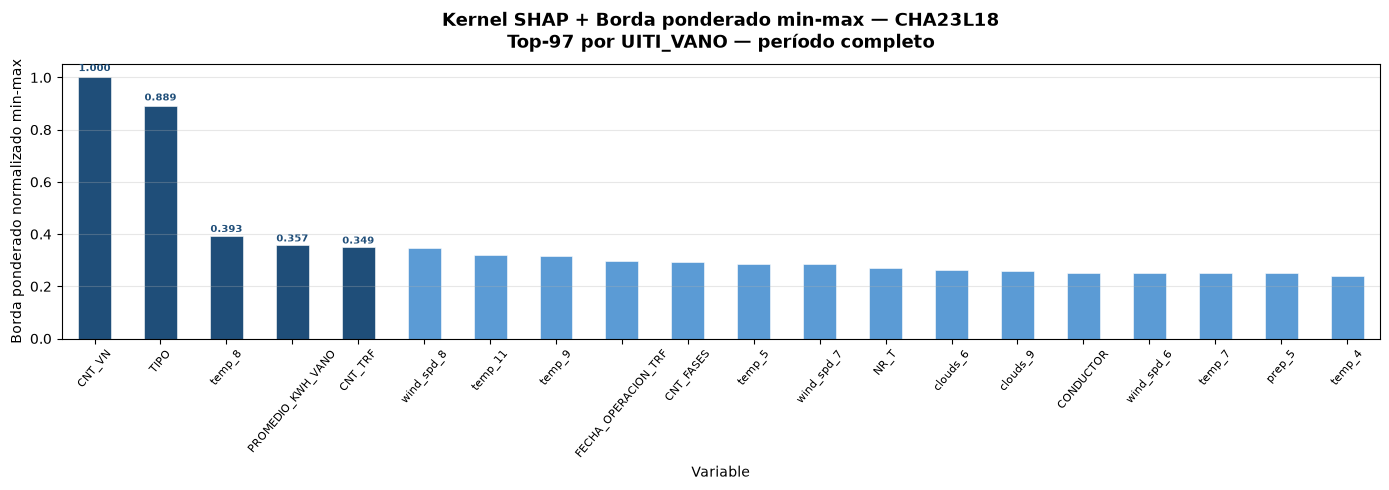

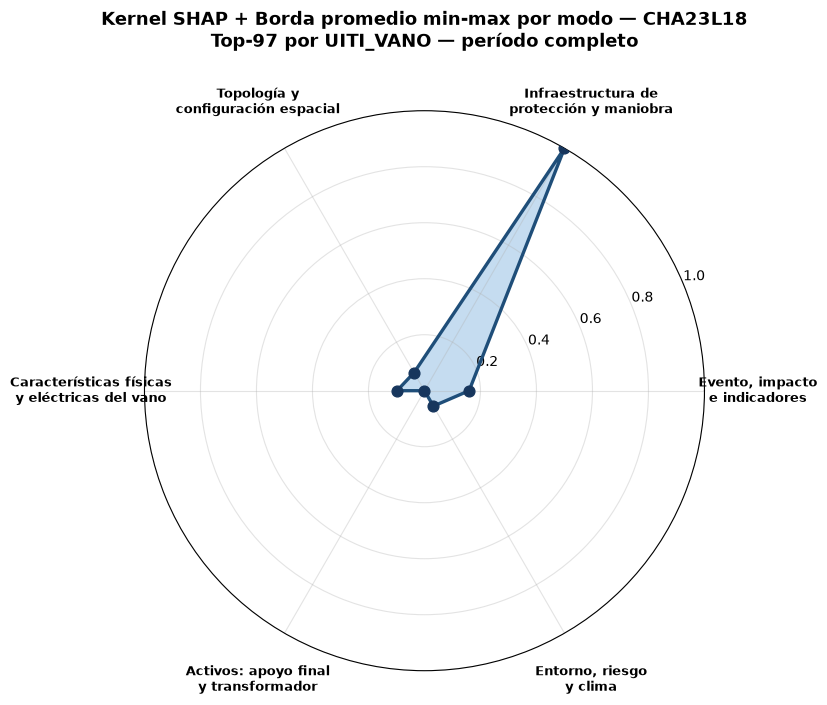

In [23]:
tabla_top_uiti = (
    tabla_periodo_tb
    .sort_values("UITI_VANO_PROM", ascending=False, kind="stable")
    .head(n_top)
    .reset_index(drop=True)
)
ids_top_uiti  = tabla_top_uiti["FID_VANO"].tolist()
base_top_uiti = base_tb[base_tb["FID_VANO"].isin(ids_top_uiti)].copy()

resultado_top_uiti = graficar_barras_y_radar(
    base_top_uiti,
    f"Top-{n_top} por UITI_VANO — período completo",
    circuito=CIRCUITO_INTERES,
    features=features,
    modos=MODOS,
    shap_extractor=shap_extractor,
    top_k=TOP_K_VARS,
)
resultado_top_uiti["contexto"] = construir_contexto_escenario_tabnet(
    nombre=f"Top-{n_top} por UITI_VANO — período completo",
    criterio="ordenar por UITI_VANO_PROM descendente en el período completo",
    resultado=resultado_top_uiti,
    tabla_top=tabla_top_uiti,
    modos=MODOS,
    top_k=TOP_K_VARS,
    ventana_climatica_horas=VENTANA_CLIMATICA_HORAS,
)
tabnet_results["top_uiti_periodo"] = resultado_top_uiti


### 8.4 Top-97 por frecuencia — período completo

Top-97 por frecuencia — período completo | eventos: 133 | vanos: 97


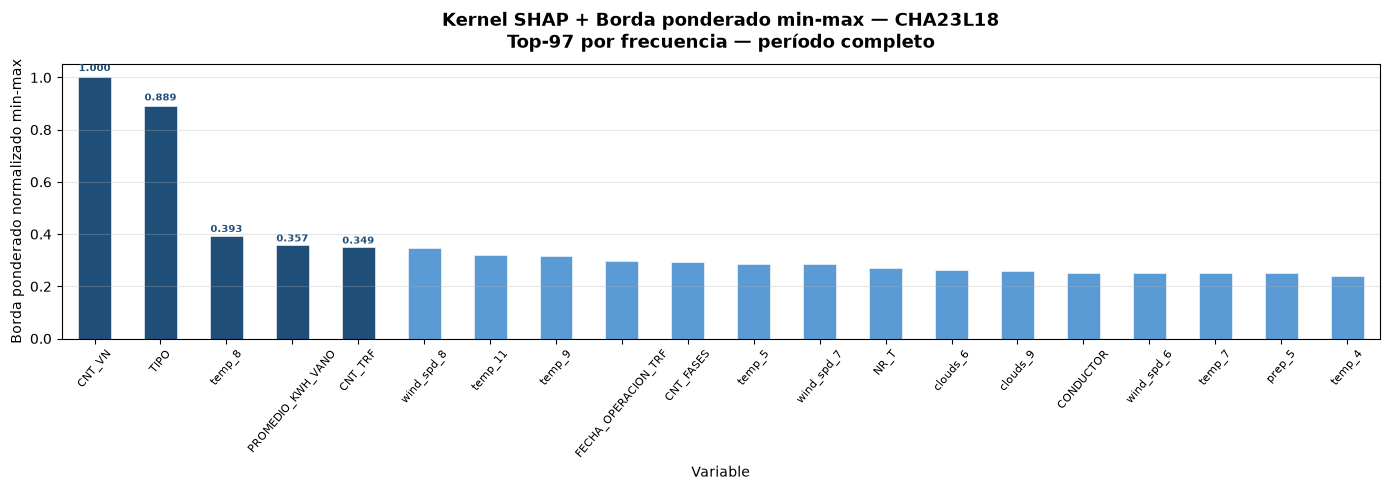

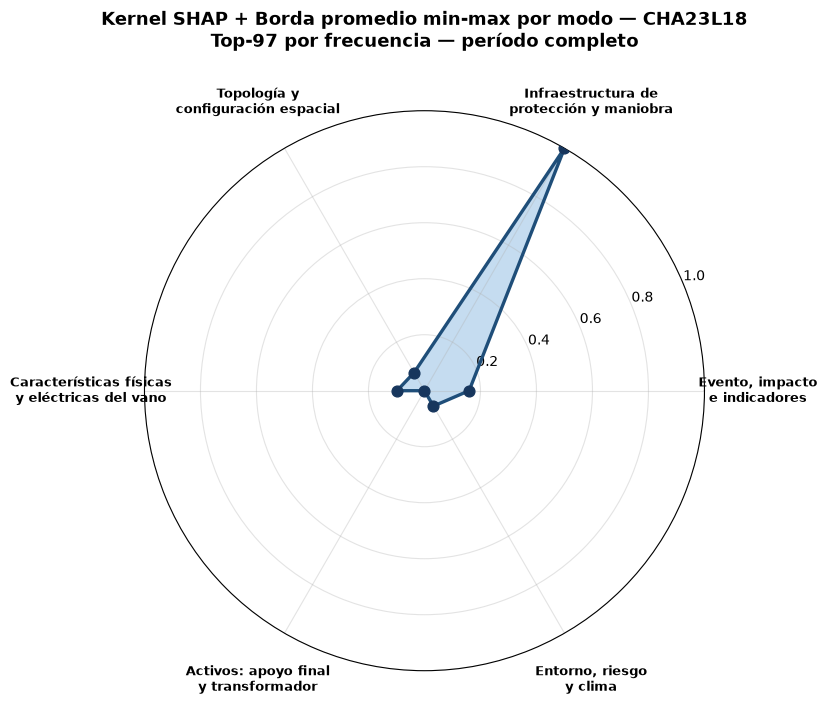

In [24]:
tabla_top_frecuencia = (
    tabla_periodo_tb
    .sort_values(["N_APARICIONES", "UITI_VANO_PROM"], ascending=[False, False], kind="stable")
    .head(n_top)
    .reset_index(drop=True)
)
ids_top_frecuencia  = tabla_top_frecuencia["FID_VANO"].tolist()
base_top_frecuencia = base_tb[base_tb["FID_VANO"].isin(ids_top_frecuencia)].copy()

resultado_top_frecuencia = graficar_barras_y_radar(
    base_top_frecuencia,
    f"Top-{n_top} por frecuencia — período completo",
    circuito=CIRCUITO_INTERES,
    features=features,
    modos=MODOS,
    shap_extractor=shap_extractor,
    top_k=TOP_K_VARS,
)
resultado_top_frecuencia["contexto"] = construir_contexto_escenario_tabnet(
    nombre=f"Top-{n_top} por frecuencia — período completo",
    criterio="ordenar por N_APARICIONES descendente y usar UITI_VANO_PROM como desempate",
    resultado=resultado_top_frecuencia,
    tabla_top=tabla_top_frecuencia,
    modos=MODOS,
    top_k=TOP_K_VARS,
    ventana_climatica_horas=VENTANA_CLIMATICA_HORAS,
)
tabnet_results["top_frecuencia_periodo"] = resultado_top_frecuencia


### 8.5 Top-97 — puntos críticos

Las fechas se derivan automáticamente de `critical_points` (celda 6). Cambia el circuito o el período en las celdas superiores y este escenario se actualiza solo. Se calculan dos lecturas: gravedad (`UITI_VANO_PROM`) y número de eventos (`N_APARICIONES`).


Top-83 por UITI_VANO — puntos críticos (2026-01-15, 2026-04-26, 2026-03-02, 2026-04-11, 2026-03-30) | eventos: 104 | vanos: 83


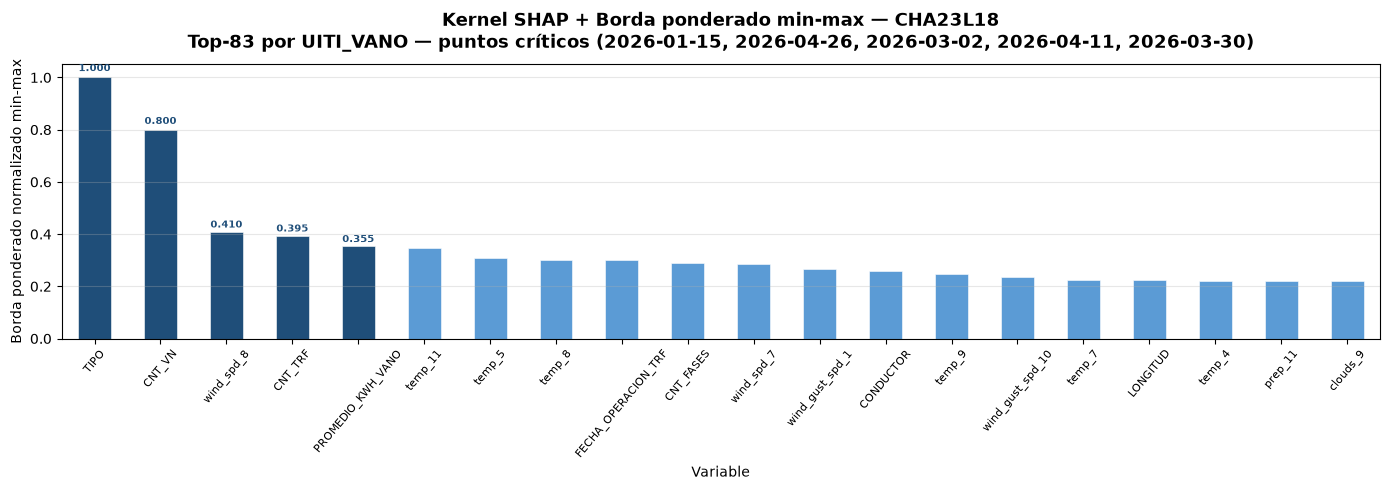

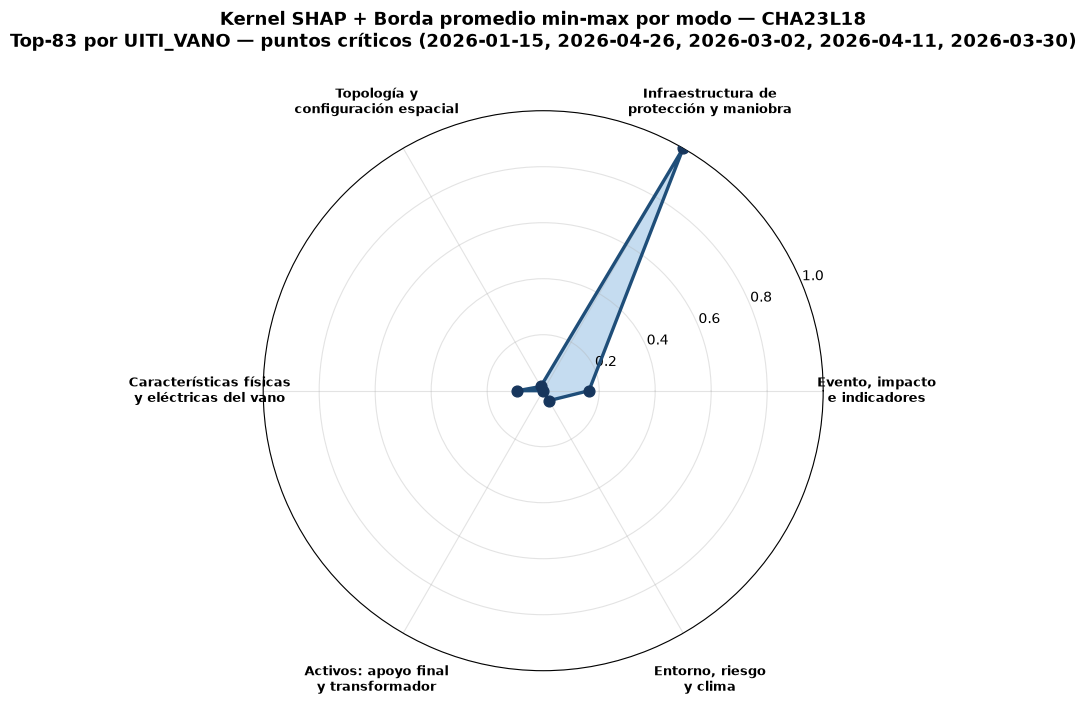

Top-83 por frecuencia — puntos críticos (2026-01-15, 2026-04-26, 2026-03-02, 2026-04-11, 2026-03-30) | eventos: 104 | vanos: 83


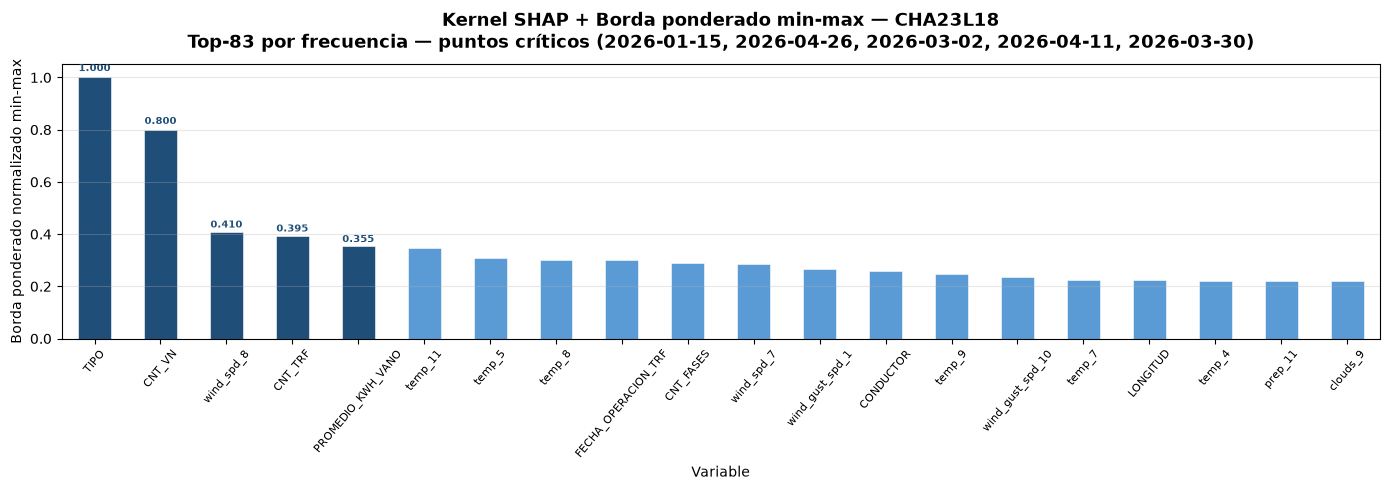

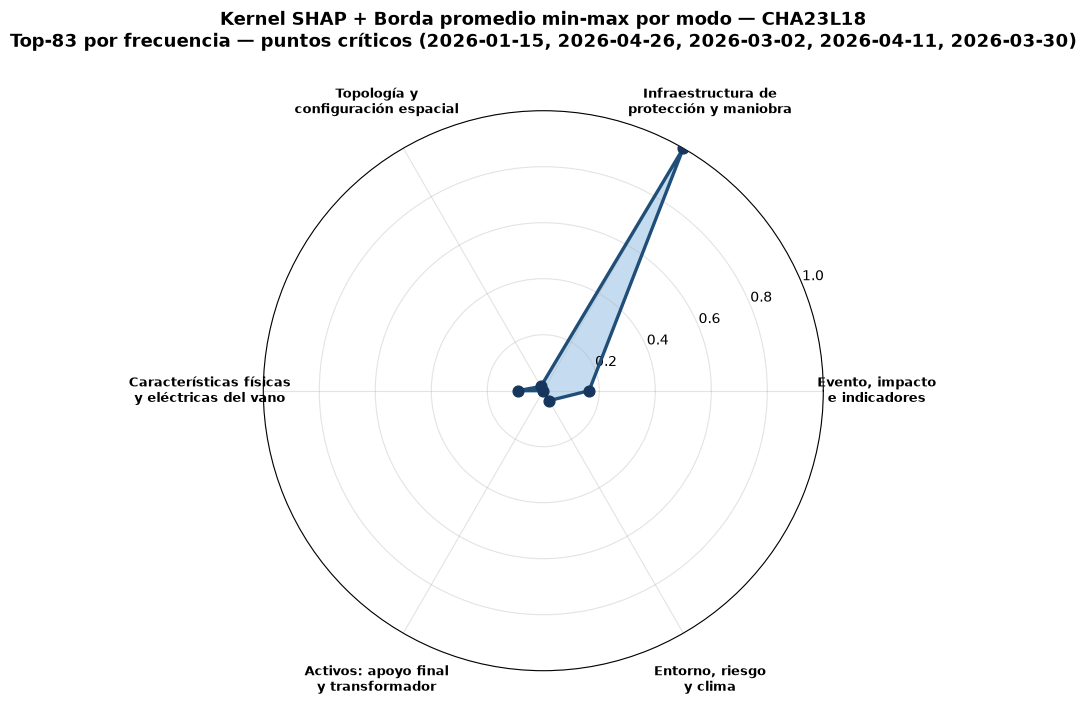

In [25]:
base_fechas_tb = base_tb[base_tb["_FECHA_DIA"].isin(FECHAS_INTERES)].copy()
if base_fechas_tb.empty:
    raise ValueError(f"No hay eventos de inferencia para las fechas críticas: {FECHAS_INTERES}")

tabla_fechas_tb = agrupar_por_vano(base_fechas_tb)
n_top_fechas = min(TOP_N_VANOS, len(tabla_fechas_tb))
fechas_label = ", ".join(FECHAS_INTERES)

# Gravedad en puntos críticos
tabla_top_fechas_uiti = (
    tabla_fechas_tb
    .sort_values("UITI_VANO_PROM", ascending=False, kind="stable")
    .head(n_top_fechas)
    .reset_index(drop=True)
)
ids_top_fechas_uiti = tabla_top_fechas_uiti["FID_VANO"].tolist()
base_top_fechas_uiti = base_fechas_tb[base_fechas_tb["FID_VANO"].isin(ids_top_fechas_uiti)].copy()

resultado_top_fechas_uiti = graficar_barras_y_radar(
    base_top_fechas_uiti,
    f"Top-{n_top_fechas} por UITI_VANO — puntos críticos ({fechas_label})",
    circuito=CIRCUITO_INTERES,
    features=features,
    modos=MODOS,
    shap_extractor=shap_extractor,
    top_k=TOP_K_VARS,
)
resultado_top_fechas_uiti["contexto"] = construir_contexto_escenario_tabnet(
    nombre=f"Top-{n_top_fechas} por UITI_VANO — puntos críticos",
    criterio="filtrar fechas críticas y ordenar por UITI_VANO_PROM descendente",
    resultado=resultado_top_fechas_uiti,
    tabla_top=tabla_top_fechas_uiti,
    modos=MODOS,
    top_k=TOP_K_VARS,
    fechas_interes=FECHAS_INTERES,
    ventana_climatica_horas=VENTANA_CLIMATICA_HORAS,
)
tabnet_results["top_uiti_puntos_criticos"] = resultado_top_fechas_uiti

# Número de eventos en puntos críticos
tabla_top_fechas_frecuencia = (
    tabla_fechas_tb
    .sort_values(["N_APARICIONES", "UITI_VANO_PROM"], ascending=[False, False], kind="stable")
    .head(n_top_fechas)
    .reset_index(drop=True)
)
ids_top_fechas_frecuencia = tabla_top_fechas_frecuencia["FID_VANO"].tolist()
base_top_fechas_frecuencia = base_fechas_tb[base_fechas_tb["FID_VANO"].isin(ids_top_fechas_frecuencia)].copy()

resultado_top_fechas_frecuencia = graficar_barras_y_radar(
    base_top_fechas_frecuencia,
    f"Top-{n_top_fechas} por frecuencia — puntos críticos ({fechas_label})",
    circuito=CIRCUITO_INTERES,
    features=features,
    modos=MODOS,
    shap_extractor=shap_extractor,
    top_k=TOP_K_VARS,
)
resultado_top_fechas_frecuencia["contexto"] = construir_contexto_escenario_tabnet(
    nombre=f"Top-{n_top_fechas} por frecuencia — puntos críticos",
    criterio="filtrar fechas críticas y ordenar por N_APARICIONES descendente, usando UITI_VANO_PROM como desempate",
    resultado=resultado_top_fechas_frecuencia,
    tabla_top=tabla_top_fechas_frecuencia,
    modos=MODOS,
    top_k=TOP_K_VARS,
    fechas_interes=FECHAS_INTERES,
    ventana_climatica_horas=VENTANA_CLIMATICA_HORAS,
)
tabnet_results["top_frecuencia_puntos_criticos"] = resultado_top_fechas_frecuencia


### 8.6 Agente de inferencias — discusión estructurada para HTML


In [26]:
tabnet_context_package = construir_contexto_tabnet(
    circuito_interes=CIRCUITO_INTERES,
    fecha_inicio=FECHA_INICIO,
    fecha_fin=FECHA_FIN,
    fechas_interes=FECHAS_INTERES,
    top_n_vanos=TOP_N_VANOS,
    top_k_vars=TOP_K_VARS,
    filtro_uiti_max=FILTRO_UITI_MAX,
    ventana_climatica_horas=VENTANA_CLIMATICA_HORAS,
    features=features,
    base=base_tb,
    escenarios=[resultado["contexto"] for resultado in tabnet_results.values()],
    modelo=type(modelo_tb).__name__,
)

tabnet_context_path = save_json_artifact(
    tabnet_context_package,
    OUTPUT_DIR / f"tabnet_structured_context_{timestamp}.json",
)

missing_tabnet_skills = verify_required_skills(profile="tabnet")
if missing_tabnet_skills:
    raise FileNotFoundError(f"Missing required TabNet LLM skills: {missing_tabnet_skills}")

tabnet_skill_bundle = assemble_skill_bundle(profile="tabnet")
tabnet_prompt = construir_prompt_tabnet(tabnet_context_package, tabnet_skill_bundle)
tabnet_prompt_path = save_prompt_artifact(tabnet_prompt, OUTPUT_DIR / f"tabnet_llm_prompt_{timestamp}.md")

print(f"TabNet context saved: {tabnet_context_path}")
print(f"TabNet prompt saved : {tabnet_prompt_path}")
print(f"TabNet skills loaded: {list_available_skills(profile='tabnet')}")


TabNet context saved: outputs/tabnet_structured_context_20260618T221201Z.json
TabNet prompt saved : outputs/tabnet_llm_prompt_20260618T221201Z.md
TabNet skills loaded: ['01_structured_context_builder.md', '02_circuit_scenario_interpreter.md', '03_uiti_vano_behavior_explainer.md', '04_graph_connectivity_guardrails.md', '05_llm_output_validator.md']


### 8.7 Llamada y validación del agente TabNet


In [27]:
tabnet_validation_data = None
tabnet_llm_result = call_llm(
    tabnet_prompt,
    provider=LLM_PROVIDER,
    model=LLM_MODEL,
    call_enabled=CALL_LLM,
    display_progress=True,
    display_content=False,
)
print(tabnet_llm_result.message)

if tabnet_llm_result.output_text:
    tabnet_validation = validar_respuesta_tabnet(tabnet_llm_result.output_text, tabnet_context_package)
    if tabnet_validation["ok"]:
        tabnet_validation_data = tabnet_validation["data"]
        tabnet_analysis_path = save_json_artifact(
            tabnet_validation_data,
            OUTPUT_DIR / f"tabnet_llm_analysis_{timestamp}.json",
        )
        print(f"TabNet LLM analysis saved: {tabnet_analysis_path}")
    else:
        raw_path, errors_path = save_invalid_output(
            tabnet_llm_result.output_text,
            tabnet_validation["errors"],
            OUTPUT_DIR,
            f"tabnet_{timestamp}",
        )
        print("La salida del agente de inferencias no validó; se guardó como inválida y no se presentará como análisis final.")
        print(f"Raw: {raw_path}")
        print(f"Errors: {errors_path}")
else:
    print("Agente de inferencias no ejecutado o sin salida; el HTML incluirá gráficas de inferencia sin discusión de ese agente.")


LLM call completed successfully.
TabNet LLM analysis saved: outputs/tabnet_llm_analysis_20260618T221201Z.json


## 9. Save artifacts

In [28]:
context_path = save_json_artifact(context_package, OUTPUT_DIR / f"structured_context_{timestamp}.json")
critical_csv_path = OUTPUT_DIR / f"critical_points_{timestamp}.csv"
critical_points_frame(critical_points).to_csv(critical_csv_path, index=False)
plot_path = save_uiti_vano_plot(
    daily_df,
    critical_points,
    selected_circuitos=selected_circuitos_effective,
    start_date=start_effective,
    end_date=end_effective,
    output_path=OUTPUT_DIR / f"uiti_vano_timeseries_{timestamp}.png",
)
print(context_path)
print(critical_csv_path)
print(plot_path)

outputs/structured_context_20260618T221201Z.json
outputs/critical_points_20260618T221201Z.csv
outputs/uiti_vano_timeseries_20260618T221201Z.png


## 10. LLM skills, contracts, and validation

In [29]:
# El agente base usa la misma configuración de proveedor/modelo que el agente de inferencias.
# No se hace verificación previa ni descarga de modelos en esta celda: `call_llm` usará
# el proveedor configurado y reportará de forma clara si no hay credenciales o servicio.
print(f"CALL_LLM   : {CALL_LLM}")
print(f"LLM_PROVIDER: {LLM_PROVIDER}")
print(f"LLM_MODEL   : {LLM_MODEL}")


CALL_LLM   : True
LLM_PROVIDER: google
LLM_MODEL   : gemini-2.5-flash


In [30]:
missing_skills = verify_required_skills()
if missing_skills:
    raise FileNotFoundError(f"Missing required LLM skills: {missing_skills}")
skills = list_available_skills()
skill_bundle = assemble_skill_bundle()
output_schema = load_output_schema()
prompt = render_prompt(
    context_json=json.dumps(context_package, ensure_ascii=False),
    output_schema_json=json.dumps(output_schema, ensure_ascii=False),
    prompt_version=PROMPT_VERSION,
)
prompt_path = save_prompt_artifact(prompt, OUTPUT_DIR / f"llm_prompt_{timestamp}.md")
print(f"Loaded skills: {skills}")
print(f"Prompt saved: {prompt_path}")
print(f"Skill bundle characters: {len(skill_bundle)}")

Loaded skills: ['01_structured_context_builder.md', '02_critical_point_interpreter.md', '03_uiti_vano_behavior_explainer.md', '04_domain_grounding_guardrails.md', '05_llm_output_validator.md']
Prompt saved: outputs/llm_prompt_20260618T221201Z.md
Skill bundle characters: 6963


In [31]:
validation_data = None
last_base_llm_result = None
last_base_validation = None

base_prompt_attempts = [prompt]
for attempt_idx, current_prompt in enumerate(base_prompt_attempts, start=1):
    llm_result = call_llm(
        current_prompt,
        provider=LLM_PROVIDER,
        model=LLM_MODEL,
        call_enabled=CALL_LLM,
        display_progress=True,
    display_content=False,
    )
    last_base_llm_result = llm_result
    print(f"Intento agente base {attempt_idx}: {llm_result.message}")

    if not llm_result.output_text:
        continue

    validation = validate_llm_response(llm_result.output_text, context_package, output_schema)
    last_base_validation = validation
    if validation.ok and validation.data:
        validation_data = validation.data
        analysis_path = save_json_artifact(
            validation_data,
            OUTPUT_DIR / f"llm_analysis_{timestamp}.json",
        )
        print(f"LLM analysis JSON saved: {analysis_path}")
        break

    raw_path, errors_path = save_invalid_output(
        llm_result.output_text,
        validation.errors,
        OUTPUT_DIR,
        f"base_attempt_{attempt_idx}_{timestamp}",
    )
    print("La salida del agente base no validó; se guardó para revisión.")
    print(f"Raw: {raw_path}")
    print(f"Errors: {errors_path}")

    if attempt_idx == 1:
        repair_prompt = f"""
{prompt}

---

La respuesta anterior NO cumplió el contrato JSON o las reglas de validación.
Errores detectados:
{json.dumps(validation.errors, ensure_ascii=False, indent=2)}

Vuelve a responder desde cero con SOLO JSON válido, sin markdown, sin texto adicional,
respetando exactamente el schema entregado y usando únicamente fechas, critical_point_id,
variables y resúmenes presentes en el contexto.
"""
        base_prompt_attempts.append(repair_prompt)

if validation_data is None:
    message = "El agente base no produjo un JSON válido. No se generará el HTML."
    if last_base_validation is not None:
        message += f" Últimos errores: {last_base_validation.errors}"
    elif last_base_llm_result is not None:
        message += f" Último estado: {last_base_llm_result.message}"
    raise RuntimeError(message)


Intento agente base 1: LLM call completed successfully.
LLM analysis JSON saved: outputs/llm_analysis_20260618T221201Z.json


# 11 Html results visualization

In [32]:
from chec_local_interpreter.plotting import render_llm_analysis

if not globals().get("validation_data"):
    raise RuntimeError("validation_data está vacío; no se genera HTML sin análisis base válido.")

html_path = render_llm_analysis(
    validation_data=validation_data,
    raw_df=raw_df,
    daily_df=daily_df,
    critical_points=critical_points,
    selected_circuitos=selected_circuitos_effective,
    start_date=start_effective,
    end_date=end_effective,
    llm_model=LLM_MODEL,
    llm_provider=LLM_PROVIDER,
    tabnet_results=globals().get("tabnet_results", {}),
    tabnet_analysis=globals().get("tabnet_validation_data", None),
)
print(
    f"\n>>> HTML Analysis Report guardado en la ruta de outputs: "
    f"{html_path}"
)

✅ **Reporte generado y guardado exitosamente:** [/Users/andresalvarez/Documents/chec-local-uiti-vano-interpreter/notebooks/notebooks/outputs/CHA23L18_20251123_20260426_20260618T171447.html](/Users/andresalvarez/Documents/chec-local-uiti-vano-interpreter/notebooks/notebooks/outputs/CHA23L18_20251123_20260426_20260618T171447.html)


>>> HTML Analysis Report guardado en la ruta de outputs: notebooks/outputs/CHA23L18_20251123_20260426_20260618T171447.html
